# 4 — With and without VirtualiZarr: what it actually costs

Notebooks [1](1_test_virtualizarr.ipynb)–[3](3_real_example_pipeline.ipynb) established that a
virtual NISAR cube works and produces a defensible signal. This one asks the question a colleague
deciding whether to bother would ask: **how much faster is it, and how much less data moves?**

One analysis — the Paradise field backscatter median over the full track — run four ways:

| | Path | Where |
|---|---|---|
| **A** | Icechunk virtual cube, direct S3 | measured here, in-region |
| **B** | Open each HDF5 granule, direct S3 | measured here, in-region |
| **C** | Open each HDF5 granule over HTTPS | measured here, in-region |
| **D** | Download the granules first, then analyse | modelled from file sizes |

## What "local" means in this notebook, and what it doesn't

This platform (CryoCloud) runs in AWS **us-west-2** — the same region as the NISAR archive. So
every path here is measured with a fast, low-latency link to the data. That makes A, B and C an
honest comparison *with each other*, and it makes none of them a measurement of what a laptop
would experience.

Off-AWS users differ in two ways. First, **they cannot use direct S3 at all** — the credentials
are region-scoped, so they are forced onto the HTTPS endpoint. Path C measures exactly that
protocol switch, in isolation, with the network held constant. Second, they have a slower, higher
latency link. That part cannot be measured from here, so section 8 **models** it arithmetically
from the measured byte counts and request counts, with the assumptions written down. A model is
labelled as a model everywhere it appears.

In [1]:
import sys, time, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, ".")

from pathlib import Path
import numpy as np, pandas as pd, geopandas as gpd
import h5py, s3fs, rioxarray  # noqa: F401
import matplotlib.pyplot as plt, matplotlib as mpl
import icechunk, earthaccess
import nisar_virtual as nv

icechunk.set_logs_filter("error")
nv.earthaccess.login(strategy="netrc")

EPSG = 32610
GEOM = Path("/home/jovyan/repos/nisar/geometries")
REPO_PATH = Path.home() / "nisar_cubes" / "rainier_gcov"
SUMMIT = (-121.7603, 46.8523)
BBOX = (SUMMIT[0] - 0.1807, SUMMIT[1] - 0.1050, SUMMIT[0] + 0.1807, SUMMIT[1] + 0.1050)

field_gdf = gpd.read_file(GEOM / "paradise_road_loop_snow_field.geojson")
north_gdf = gpd.read_file(GEOM / "snotel_field_north.geojson")

SURFACE, INK, INK2 = "#fcfcfb", "#0b0b0b", "#52514e"
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2, "axes.edgecolor": "#d8d7d2",
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#ecebe7", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "figure.dpi": 120, "legend.frameon": False,
})
RESULTS = {}
print("ready")

ready


---
## 1. The task, defined once

Median HH γ⁰ over the north Paradise field, for every acquisition on descending track 065's
dominant output grid. A small AOI over a long series — the shape of analysis a virtual cube should
be good at, and the shape most snow and ice work actually has.

Both the S3 and HTTPS URL for each granule, so paths B and C read the *same bytes* over different
protocols.

In [2]:
res = earthaccess.search_data(short_name="NISAR_L2_GCOV_PROVISIONAL_V1",
                              bounding_box=BBOX, count=200)
pairs = []
for g in res:
    direct = [u for u in g.data_links(access="direct") if u.endswith(".h5")]
    over_https = [u for u in g.data_links() if u.endswith(".h5")]
    if direct and over_https:
        name = direct[0].rsplit("/", 1)[-1]
        if "_172_" in name and "_D_065_" in name:      # the dominant grid, track 065 D
            pairs.append((direct[0], over_https[0]))
# The archive holds more than one product version of some takes. Left in, path B
# would open 24 files to produce 23 distinct dates while path A read 23 - and the
# benchmark would be quietly unfair. Keep the highest version per acquisition.
import re
VER, STAMP = re.compile(r"_(\d{3})\.h5$"), re.compile(r"_(\d{8}T\d{6})_")
best = {}
for d, h in sorted(set(pairs)):
    name = d.rsplit("/", 1)[-1]
    stamp = STAMP.search(name).group(1)
    version = int(m.group(1)) if (m := VER.search(name)) else 0
    if version >= best.get(stamp, (-1,))[0]:
        best[stamp] = (version, d, h)
raw = len(set(pairs))
pairs = [(d, h) for _, (_, d, h) in sorted(best.items())]
N = len(pairs)
print(f"{N} granules on track D 065's dominant grid "
      f"({raw - N} superseded product version(s) dropped)")
print(f"  s3    {pairs[0][0][:96]}")
print(f"  https {pairs[0][1][:96]}")

23 granules on track D 065's dominant grid (1 superseded product version(s) dropped)
  s3    s3://sds-n-cumulus-prod-nisar-products/NISAR_L2_GCOV_PROVISIONAL_V1/NISAR_L2_PR_GCOV_004_172_D_0
  https https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_PROVISIONAL_V1/NISAR_L2_PR_GCOV_00


In [3]:
# The AOI as a pixel window on that grid, so every path reads an identical region.
X0, Y0, PS = 334805.0, 5320075.0, 10.0          # grid origin and posting
minx, miny, maxx, maxy = field_gdf.to_crs(EPSG).total_bounds
PAD = 200
IX0 = int((minx - PAD - X0) // PS); IX1 = int((maxx + PAD - X0) // PS) + 1
IY0 = int((Y0 - (maxy + PAD)) // PS); IY1 = int((Y0 - (miny - PAD)) // PS) + 1
print(f"AOI window  y[{IY0}:{IY1}]  x[{IX0}:{IX1}]  = {IY1-IY0} x {IX1-IX0} px "
      f"({(IX1-IX0)*PS/1000:.2f} x {(IY1-IY0)*PS/1000:.2f} km)")

CHUNK = 512
CY = (IY0 // CHUNK, (IY1 - 1) // CHUNK)
CX = (IX0 // CHUNK, (IX1 - 1) // CHUNK)
print(f"which lands inside chunks y[{CY[0]}..{CY[1]}] x[{CX[0]}..{CX[1]}] "
      f"-> {(CY[1]-CY[0]+1) * (CX[1]-CX[0]+1)} chunks of {CHUNK}x{CHUNK} per granule")

AOI window  y[13777:13874]  x[26027:26126]  = 97 x 99 px (0.99 x 0.97 km)
which lands inside chunks y[26..27] x[50..51] -> 4 chunks of 512x512 per granule


### How much is this granule, and how much is the answer?

Worth having the two extremes on the table before measuring anything in between.

In [4]:
import obstore
registry = nv.obstore_registry()
sizes = []
for s3url, _ in pairs:
    st, p = registry.resolve(s3url)
    sizes.append(obstore.head(st, p)["size"])
GRANULE_BYTES = int(np.mean(sizes))
ARCHIVE_BYTES = int(np.sum(sizes))
ANSWER_BYTES = N * 8            # N float64 medians

print(f"one granule          : {GRANULE_BYTES/1e9:6.2f} GB")
print(f"all {N} granules      : {ARCHIVE_BYTES/1e9:6.1f} GB")
print(f"the answer we want   : {ANSWER_BYTES} bytes ({N} float64 medians)")
print(f"\nratio               : {ARCHIVE_BYTES/ANSWER_BYTES:,.0f}x more data than answer")

one granule          :   6.89 GB
all 23 granules      :  158.4 GB
the answer we want   : 184 bytes (23 float64 medians)

ratio               : 860,652,945x more data than answer


---
## 2. Instrumentation

Two different accounting methods, and it matters which is which.

**Paths B and C** are measured at the reader: fsspec fetches byte ranges through its cache, so
patching the cache's fetcher counts every byte that actually crossed the network, and every
request that carried it. Note the patch has to go on `cache.fetcher` — the cache captured the
bound method at construction, so patching `_fetch_range` on the file object does nothing (a
mistake worth recording, because it silently reports zero).

**Path A** is computed from the chunk manifest: the byte lengths of exactly those chunks the AOI
intersects. Icechunk fetches them from Rust, where a Python counter cannot reach. The manifest is
the authoritative record of what has to be read, so this is exact rather than approximate — but it
is arithmetic, not observation, and it is labelled that way in the results.

In [5]:
def counting(f):
    # fsspec's cache holds the fetcher it was constructed with, so patch it there.
    stats = {"bytes": 0, "requests": 0}
    original = f.cache.fetcher
    def counted(start, end):
        data = original(start, end)
        stats["bytes"] += len(data); stats["requests"] += 1
        return data
    f.cache.fetcher = counted
    return stats

BLOCK = 4 * 2**20      # fsspec read-ahead block; see section 6 for the sensitivity

def s3_filesystem():
    c = nv.nisar_s3_credentials()
    return s3fs.S3FileSystem(key=c["accessKeyId"], secret=c["secretAccessKey"],
                             token=c["sessionToken"], anon=False,
                             client_kwargs={"region_name": nv.REGION})

def median_from_window(arr):
    return float(np.nanmedian(np.where(arr > 0, arr, np.nan)))

---
## 3. Path A — the virtual cube

The cube from notebook 3, already built. This is the steady state: the index exists, and every
analysis from here is a read.

In [6]:
def path_a():
    cube = nv.open_cube(nv.open_repo(REPO_PATH))
    x, y = cube.xCoordinates.values, cube.yCoordinates.values
    sub = cube.HHHH.isel(yCoordinates=slice(IY0, IY1), xCoordinates=slice(IX0, IX1))
    db = 10 * np.log10(sub.where(sub > 0))
    med = db.median(dim=("yCoordinates", "xCoordinates"), skipna=True).compute()
    return pd.Series(med.values, index=cube.time.to_index())

t0 = time.time()
a_series = path_a()
a_time = time.time() - t0

# bytes: the manifest's own record of the chunks this AOI intersects
import virtualizarr as vz
from virtualizarr.parsers import HDFParser
man = vz.open_virtual_dataset(pairs[0][0], registry=registry,
                              parser=HDFParser(group=nv.GCOV_GRIDS))["HHHH"].data.manifest
# `_lengths` is private; there is no public accessor for the whole array
per_granule = int(man._lengths[CY[0]:CY[1]+1, CX[0]:CX[1]+1].sum())
a_bytes = per_granule * len(a_series)
a_requests = (CY[1]-CY[0]+1) * (CX[1]-CX[0]+1) * len(a_series)

RESULTS["A · virtual cube, direct S3"] = dict(
    seconds=a_time, bytes=a_bytes, requests=a_requests, short="A  virtual cube · S3",
    measured="time measured; bytes from manifest")
print(f"{len(a_series)} dates in {a_time:.2f}s")
print(f"chunk bytes for the AOI : {a_bytes/1e6:.1f} MB "
      f"({per_granule/1e6:.2f} MB x {len(a_series)} granules)")
print(f"range requests implied  : {a_requests}")
print(f"\n{a_series.round(2).to_string()}")

23 dates in 2.09s
chunk bytes for the AOI : 60.7 MB (2.64 MB x 23 granules)
range requests implied  : 92

time
2025-11-10 03:18:48   -3.59
2025-11-22 03:18:48   -4.36
2025-12-04 03:18:49   -5.79
2025-12-16 03:18:49   -4.06
2025-12-28 03:18:50   -6.57
2026-01-09 03:18:50   -6.48
2026-01-21 03:18:51   -4.59
2026-02-02 03:18:52   -5.07
2026-02-14 03:18:52   -5.71
2026-02-26 03:18:53   -6.48
2026-03-10 03:18:53   -6.80
2026-03-22 03:18:53   -5.87
2026-04-03 03:18:54   -6.15
2026-04-15 03:18:54   -6.06
2026-04-27 03:18:54   -4.58
2026-05-09 03:18:53   -4.48
2026-05-21 03:18:53   -4.39
2026-06-02 03:18:52   -3.98
2026-06-14 03:18:51   -3.76
2026-06-26 03:18:50   -4.59
2026-07-08 03:18:50   -4.27
2026-07-20 03:18:49   -4.55
2026-08-13 03:18:48   -4.66


---
## 4. Path B — open every granule, direct S3

No virtualization. What the same analysis costs when each session opens all 22 files itself. This
is the honest baseline for someone already on AWS: the comparison is not "virtual versus
downloading", it is "virtual versus the normal in-region way".

In [7]:
def path_b(urls, fs):
    out, tb, tr = {}, 0, 0
    for i, url in enumerate(urls, 1):
        f = fs.open(url, "rb", block_size=BLOCK)
        st = counting(f)
        try:
            with h5py.File(f, "r") as h:
                win = h[f"{nv.GCOV_GRIDS}/HHHH"][IY0:IY1, IX0:IX1]
                stamp = h["/science/LSAR/identification/zeroDopplerStartTime"][()]
        finally:
            f.close()
        stamp = stamp.decode() if isinstance(stamp, bytes) else str(stamp)
        out[pd.to_datetime(stamp[:19])] = 10 * np.log10(median_from_window(win))
        tb += st["bytes"]; tr += st["requests"]
        if i % 5 == 0 or i == len(urls):
            print(f"  {i}/{len(urls)}  {tb/1e6:7.0f} MB, {tr} requests")
    return pd.Series(out).sort_index(), tb, tr

s3 = s3_filesystem()
t0 = time.time()
b_series, b_bytes, b_requests = path_b([d for d, _ in pairs], s3)
b_time = time.time() - t0

RESULTS["B · one HDF5 at a time, direct S3"] = dict(
    seconds=b_time, bytes=b_bytes, requests=b_requests,
    short="B  every HDF5 · S3", measured="measured")
print(f"\n{len(b_series)} dates in {b_time:.1f}s  "
      f"({b_time/len(b_series):.1f}s per granule)")
print(f"bytes over the network  : {b_bytes/1e6:.0f} MB")
print(f"range requests          : {b_requests}")

  5/23      237 MB, 55 requests


  10/23      475 MB, 110 requests


  15/23      712 MB, 165 requests


  20/23      949 MB, 220 requests


  23/23     1092 MB, 253 requests

23 dates in 18.6s  (0.8s per granule)
bytes over the network  : 1092 MB
range requests          : 253


---
## 5. Do the two paths agree?

A benchmark that compares two different answers is measuring nothing.

In [8]:
common = a_series.index.intersection(b_series.index)
comp = pd.DataFrame({"virtual (A)": a_series.reindex(common),
                     "direct  (B)": b_series.reindex(common)})
comp["Δ dB"] = comp["virtual (A)"] - comp["direct  (B)"]
print(comp.round(4).to_string())
print(f"\nmatched dates    : {len(common)} of {len(a_series)} / {len(b_series)}")
print(f"max |difference| : {comp['Δ dB'].abs().max():.2e} dB")
print(f"identical        : {np.allclose(comp['virtual (A)'], comp['direct  (B)'], atol=1e-9)}")

                     virtual (A)  direct  (B)  Δ dB
2025-11-10 03:18:48      -3.5945      -3.5945  -0.0
2025-11-22 03:18:48      -4.3567      -4.3567  -0.0
2025-12-04 03:18:49      -5.7877      -5.7877  -0.0
2025-12-16 03:18:49      -4.0600      -4.0600  -0.0
2025-12-28 03:18:50      -6.5697      -6.5697   0.0
2026-01-09 03:18:50      -6.4765      -6.4765  -0.0
2026-01-21 03:18:51      -4.5892      -4.5892  -0.0
2026-02-02 03:18:52      -5.0720      -5.0720  -0.0
2026-02-14 03:18:52      -5.7105      -5.7105  -0.0
2026-02-26 03:18:53      -6.4787      -6.4787  -0.0
2026-03-10 03:18:53      -6.7999      -6.7999  -0.0
2026-03-22 03:18:53      -5.8714      -5.8714  -0.0
2026-04-03 03:18:54      -6.1487      -6.1487  -0.0
2026-04-15 03:18:54      -6.0575      -6.0575   0.0
2026-04-27 03:18:54      -4.5772      -4.5772  -0.0
2026-05-09 03:18:53      -4.4848      -4.4848  -0.0
2026-05-21 03:18:53      -4.3940      -4.3940  -0.0
2026-06-02 03:18:52      -3.9840      -3.9840  -0.0
2026-06-14 0

---
## 6. Path C — the same thing over HTTPS

Off-AWS users cannot use direct S3: the credentials are region-scoped. They go through the DAAC's
HTTPS endpoint instead. Measuring that here, from inside the region, isolates the cost of the
protocol switch from the cost of a slower network — the network is the same as path B's.

In [9]:
https = earthaccess.get_fsspec_https_session()
t0 = time.time()
c_series, c_bytes, c_requests = path_b([h for _, h in pairs], https)
c_time = time.time() - t0

RESULTS["C · one HDF5 at a time, HTTPS"] = dict(
    seconds=c_time, bytes=c_bytes, requests=c_requests,
    short="C  every HDF5 · HTTPS", measured="measured")
print(f"\n{len(c_series)} dates in {c_time:.1f}s ({c_time/len(c_series):.1f}s per granule)")
print(f"bytes {c_bytes/1e6:.0f} MB, {c_requests} requests")
print(f"\nagrees with path A: "
      f"{np.allclose(a_series.reindex(c_series.index), c_series, atol=1e-9)}")
print(f"HTTPS vs direct S3: {c_time/b_time:.2f}x wall time, "
      f"{c_bytes/b_bytes:.2f}x bytes")

  5/23      237 MB, 55 requests


  10/23      475 MB, 110 requests


  15/23      712 MB, 165 requests


  20/23      949 MB, 220 requests


  23/23     1092 MB, 253 requests

23 dates in 68.1s (3.0s per granule)
bytes 1092 MB, 253 requests

agrees with path A: True
HTTPS vs direct S3: 3.66x wall time, 1.00x bytes


### How much of path B and C's volume is the read-ahead block?

Both move far more than the AOI's chunks require, and part of that is fsspec reading whole blocks.
Re-running two granules at a smaller block size separates the block overshoot from the HDF5
metadata traversal that is irreducible.

In [10]:
probe = [d for d, _ in pairs][:2]
for bs in (1 * 2**20, 4 * 2**20, 16 * 2**20):
    tb = tr = 0
    t0 = time.time()
    for url in probe:
        f = s3.open(url, "rb", block_size=bs)
        st = counting(f)
        try:
            with h5py.File(f, "r") as h:
                h[f"{nv.GCOV_GRIDS}/HHHH"][IY0:IY1, IX0:IX1]
        finally:
            f.close()
        tb += st["bytes"]; tr += st["requests"]
    print(f"block {bs//2**20:2d} MB : {tb/len(probe)/1e6:6.1f} MB and "
          f"{tr//len(probe):3d} requests per granule, {(time.time()-t0)/len(probe):.1f}s each")
print(f"\nthe AOI's chunks themselves : {per_granule/1e6:6.2f} MB per granule")
print("everything above that is HDF5 B-tree traversal plus block overshoot —")
print("re-paid on every granule, in every session.")

block  1 MB :   11.8 MB and  10 requests per granule, 0.4s each


block  4 MB :   43.3 MB and  10 requests per granule, 0.5s each


block 16 MB :  167.6 MB and  10 requests per granule, 1.9s each

the AOI's chunks themselves :   2.64 MB per granule
everything above that is HDF5 B-tree traversal plus block overshoot —
re-paid on every granule, in every session.


---
## 7. Path D — download first, then analyse

Still the default workflow in a lot of places, and the one virtualization is usually pitched
against. Not performed here: 151 GB is not something to move to make a point. Computed from the
file sizes measured in section 1.

In [11]:
LINKS = {"home broadband  100 Mbit/s": 100e6,
         "good office     500 Mbit/s": 500e6,
         "in-region AWS    10 Gbit/s": 10e9}
print(f"downloading all {N} granules ({ARCHIVE_BYTES/1e9:.0f} GB):\n")
for label, bps in LINKS.items():
    secs = ARCHIVE_BYTES * 8 / bps
    print(f"  {label} : {secs/3600:6.2f} h   (then {ARCHIVE_BYTES/1e9:.0f} GB of disk)")

RESULTS["D · download all granules, then analyse"] = dict(
    seconds=ARCHIVE_BYTES * 8 / 100e6, bytes=ARCHIVE_BYTES, requests=N,
    short="D  download everything", measured="modelled at 100 Mbit/s")

downloading all 23 granules (158 GB):

  home broadband  100 Mbit/s :   3.52 h   (then 158 GB of disk)
  good office     500 Mbit/s :   0.70 h   (then 158 GB of disk)
  in-region AWS    10 Gbit/s :   0.04 h   (then 158 GB of disk)


---
## 8. Modelling a laptop

The measured numbers above all enjoy an in-region network. To say anything about a laptop, take
the **measured bytes and request counts** and put them on a slower, higher-latency link:

```
time ≈ requests × RTT  +  bytes × 8 / bandwidth
```

Two things this gets wrong, both worth stating. It charges latency **serially**, where a real
client would pipeline several requests at once — so it overstates the latency term. And it ignores
TCP ramp-up, which penalises many small transfers — so it understates the per-request cost.
Treat it as an order of magnitude, not a prediction.

In [12]:
def model(bytes_, requests, mbps, rtt_ms):
    return requests * rtt_ms / 1000 + bytes_ * 8 / (mbps * 1e6)

SCENARIOS = [("in-region (measured)", None, None),
             ("laptop, 100 Mbit/s, 30 ms RTT", 100, 30),
             ("laptop,  25 Mbit/s, 80 ms RTT", 25, 80)]

rows = []
for name, meta in RESULTS.items():
    row = {"path": name}
    for label, mbps, rtt in SCENARIOS:
        row[label] = (meta["seconds"] if mbps is None
                      else model(meta["bytes"], meta["requests"], mbps, rtt))
    rows.append(row)
model_df = pd.DataFrame(rows).set_index("path")

fmt = model_df.copy()
for c in fmt.columns:
    fmt[c] = fmt[c].map(lambda s: f"{s:,.1f} s" if s < 600 else f"{s/3600:,.2f} h")
print(fmt.to_string())
print("\nColumn 1 is measured in us-west-2. Columns 2-3 are the model above applied")
print("to the same measured byte and request counts. Path D is modelled throughout.")
print("\nB and C model identically because they move identical bytes in identical")
print("requests - the model only knows volume and latency. Their measured gap is")
print("protocol overhead, which is exactly why C was measured rather than assumed.")

                                        in-region (measured) laptop, 100 Mbit/s, 30 ms RTT laptop,  25 Mbit/s, 80 ms RTT
path                                                                                                                    
A · virtual cube, direct S3                            2.1 s                         7.6 s                        26.8 s
B · one HDF5 at a time, direct S3                     18.6 s                        94.9 s                       369.6 s
C · one HDF5 at a time, HTTPS                         68.1 s                        94.9 s                       369.6 s
D · download all granules, then analyse               3.52 h                        3.52 h                       14.08 h

Column 1 is measured in us-west-2. Columns 2-3 are the model above applied
to the same measured byte and request counts. Path D is modelled throughout.

B and C model identically because they move identical bytes in identical
requests - the model only knows volume and late

---
## 9. Results

In [13]:
summary = pd.DataFrame([
    {"path": name,
     "wall time (s)": m["seconds"],
     "bytes moved": m["bytes"],
     "requests": m["requests"],
     "MB": m["bytes"] / 1e6,
     "note": m["measured"]}
    for name, m in RESULTS.items()]).set_index("path")

base = summary.loc["B · one HDF5 at a time, direct S3"]
summary["× B time"] = summary["wall time (s)"] / base["wall time (s)"]
summary["× B bytes"] = summary["bytes moved"] / base["bytes moved"]
print(summary[["wall time (s)", "MB", "requests", "× B time", "× B bytes", "note"]]
      .round(3).to_string())

                                         wall time (s)          MB  requests  × B time  × B bytes                                note
path                                                                                                                                 
A · virtual cube, direct S3                      2.094      60.713        92     0.112      0.056  time measured; bytes from manifest
B · one HDF5 at a time, direct S3               18.640    1091.668       253     1.000      1.000                            measured
C · one HDF5 at a time, HTTPS                   68.130    1091.668       253     3.655      1.000                            measured
D · download all granules, then analyse      12668.811  158360.142        23   679.669    145.063              modelled at 100 Mbit/s


### The one-time cost, measured

Path A's numbers assume the cube exists. Someone has to build it, so measure that too before
claiming anything.

In [14]:
probe_n = 4
t0 = time.time()
nv.build_manifests([d for d, _ in pairs][:probe_n],
                   drop_variables=nv.drop_outside(
                       ["HHHH", "HVHV", "xCoordinates", "yCoordinates", "projection",
                        "mask", "numberOfLooks", "rtcGammaToSigmaFactor",
                        "inputDataExceptionMask", "listOfCovarianceTerms",
                        "listOfPolarizations", "numberOfSubSwaths",
                        "xCoordinateSpacing", "yCoordinateSpacing"]))
per = (time.time() - t0) / probe_n
build_total = per * N
saved_per_run = b_time - a_time
breakeven = build_total / saved_per_run

print(f"index build   : {per:.2f}s per granule -> {build_total:.0f}s for {N} granules")
print(f"saved per run : {b_time:.1f}s - {a_time:.1f}s = {saved_per_run:.1f}s")
print(f"break-even    : {breakeven:.1f} runs of this analysis")

index build   : 0.78s per granule -> 18s for 23 granules
saved per run : 18.6s - 2.1s = 16.5s
break-even    : 1.1 runs of this analysis


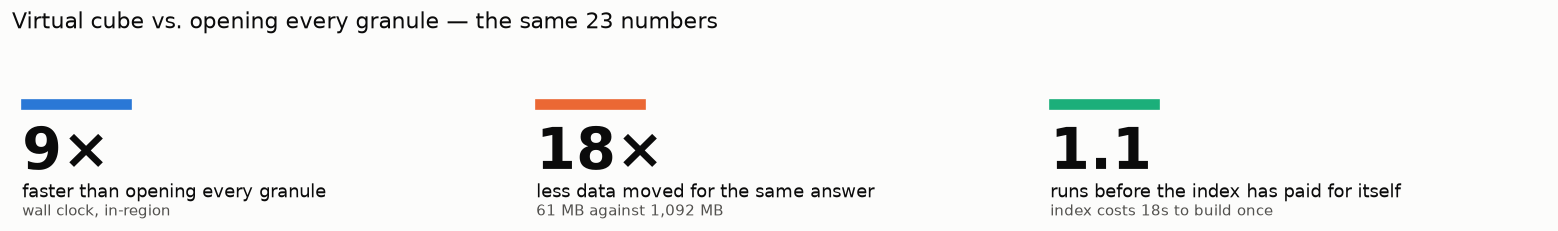

In [15]:
# --- the three numbers, before the detail ----------------------------------
tiles = [(f"{b_time / a_time:.0f}×", "faster than opening every granule",
          "wall clock, in-region", CAT[0]),
         (f"{b_bytes / a_bytes:.0f}×", "less data moved for the same answer",
          f"{a_bytes/1e6:.0f} MB against {b_bytes/1e6:,.0f} MB", CAT[1]),
         (f"{breakeven:.1f}", "runs before the index has paid for itself",
          f"index costs {build_total:.0f}s to build once", CAT[2])]

fig, axes = plt.subplots(1, 3, figsize=(13, 1.9))
for ax, (big, lab, sub, col) in zip(axes, tiles):
    ax.axis("off")
    ax.add_patch(plt.Rectangle((0.0, 0.90), 0.22, 0.07, color=col,
                               transform=ax.transAxes, clip_on=False))
    ax.text(0.0, 0.52, big, transform=ax.transAxes, fontsize=34, color=INK,
            va="center", fontweight="bold")
    ax.text(0.0, 0.20, lab, transform=ax.transAxes, fontsize=10.5, color=INK, va="center")
    ax.text(0.0, 0.04, sub, transform=ax.transAxes, fontsize=9, color=INK2, va="center")
fig.suptitle("Virtual cube vs. opening every granule — the same 23 numbers",
             x=0.005, ha="left", fontsize=13, color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.86))
plt.show()

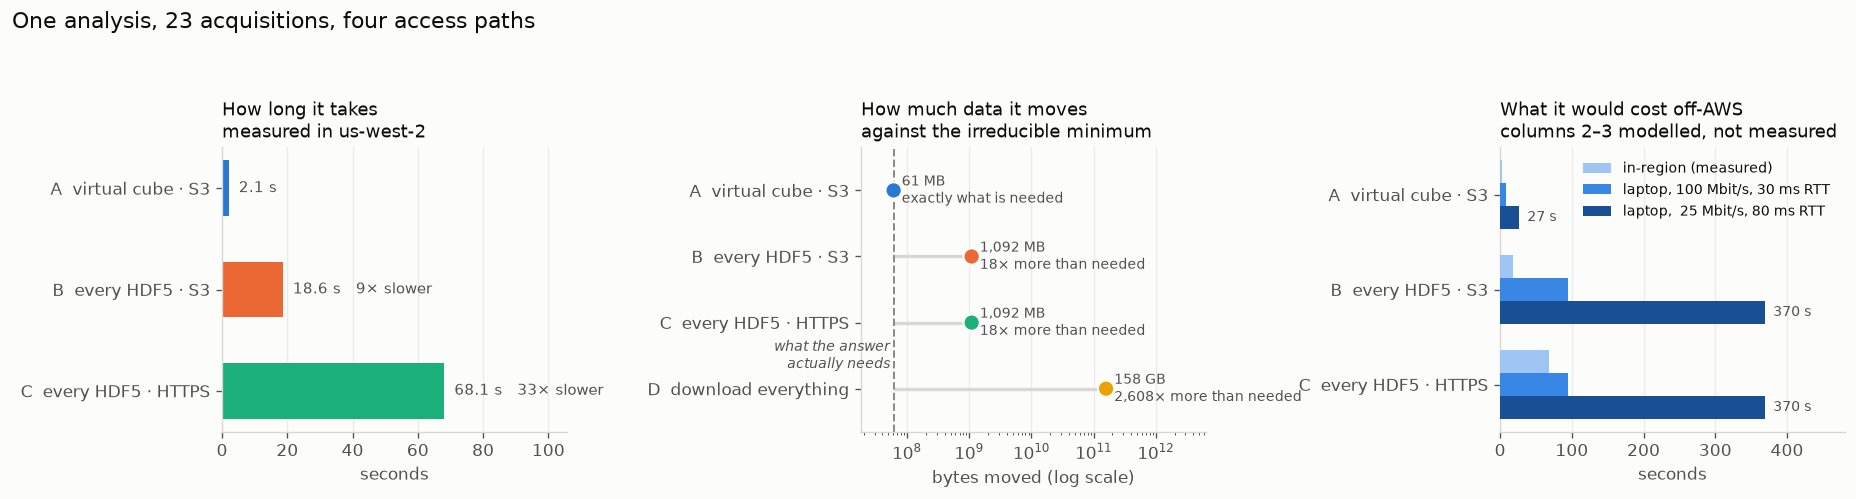

In [16]:
labels = list(RESULTS)
short = [RESULTS[l]["short"] for l in labels]
cols = [CAT[i % len(CAT)] for i in range(len(labels))]
meas = [l for l in labels if "modelled" not in RESULTS[l]["measured"]]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15.5, 4.2))

# --- (a) wall time, measured ------------------------------------------------
vals = [RESULTS[l]["seconds"] for l in meas]
ax1.barh(range(len(meas)), vals, height=0.55,
         color=[CAT[labels.index(l) % len(CAT)] for l in meas])
for i, (l, v) in enumerate(zip(meas, vals)):
    mult = "" if l == meas[0] else f"   {v / vals[0]:.0f}× slower"
    ax1.text(v, i, f"  {v:.1f} s{mult}", va="center", fontsize=9, color=INK2)
ax1.set_yticks(range(len(meas))); ax1.set_yticklabels([short[labels.index(l)] for l in meas])
ax1.invert_yaxis(); ax1.grid(axis="x"); ax1.set_axisbelow(True)
ax1.set_xlabel("seconds"); ax1.set_xlim(0, max(vals) * 1.55)
ax1.set_title("How long it takes\nmeasured in us-west-2", loc="left", color=INK)

# --- (b) data moved, against what the answer actually needs -----------------
xs = [RESULTS[l]["bytes"] for l in labels]
NEED = a_bytes                      # the chunks the AOI intersects: the floor
ax2.axvline(NEED, color="#8c8b86", lw=1.2, ls="--", zorder=2)
ax2.text(NEED * 0.88, len(labels) - 1.5, "what the answer\nactually needs",
         ha="right", va="center", fontsize=8.5, color=INK2, style="italic")
ax2.hlines(range(len(labels)), NEED, xs, color="#d8d7d2", lw=2, zorder=1)
ax2.scatter(xs, range(len(labels)), s=95, color=cols, zorder=3,
            edgecolor="white", linewidth=1.2)
for i, v in enumerate(xs):
    size = f"{v/1e6:,.0f} MB" if v < 1e10 else f"{v/1e9:,.0f} GB"
    over = "exactly what is needed" if v <= NEED * 1.02 else f"{v/NEED:,.0f}× more than needed"
    ax2.text(v * 1.35, i, f"{size}\n{over}", va="center", fontsize=8.5, color=INK2)
ax2.set_xscale("log"); ax2.set_xlim(NEED * 0.30, max(xs) * 40)
ax2.set_yticks(range(len(labels))); ax2.set_yticklabels(short)
ax2.set_ylim(len(labels) - 0.35, -0.65)      # room for the two-line labels
ax2.grid(axis="x"); ax2.set_axisbelow(True)
ax2.set_xlabel("bytes moved (log scale)")
ax2.set_title("How much data it moves\nagainst the irreducible minimum", loc="left", color=INK)

# --- (c) what happens off-AWS ----------------------------------------------
# scenarios are ordered by how bad the link is, so a sequential ramp rather
# than categorical hues: light = fast, dark = slow.
RAMP = ["#9ec5f4", "#3987e5", "#184f95"]
scen = list(model_df.columns)
h = 0.24
for j, sc in enumerate(scen):
    ax3.barh([i + (j - 1) * h for i in range(len(meas))],
             [model_df.loc[l, sc] for l in meas], height=h,
             color=RAMP[j], label=sc, zorder=3)
for i, l in enumerate(meas):
    v = model_df.loc[l, scen[-1]]
    ax3.text(v, i + h, f"  {v:.0f} s", va="center", fontsize=8.5, color=INK2)
ax3.set_yticks(range(len(meas))); ax3.set_yticklabels([short[labels.index(l)] for l in meas])
ax3.invert_yaxis(); ax3.grid(axis="x"); ax3.set_axisbelow(True)
ax3.set_xlabel("seconds"); ax3.set_xlim(0, model_df[scen[-1]].loc[meas].max() * 1.30)
ax3.legend(fontsize=8.5, loc="upper right", borderaxespad=0.6)
ax3.set_title("What it would cost off-AWS\ncolumns 2–3 modelled, not measured", loc="left",
              color=INK)

fig.suptitle(f"One analysis, {len(a_series)} acquisitions, four access paths",
             x=0.005, ha="left", fontsize=13, color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()

---
## 10. When does building the index pay for itself?

The index is paid for **once**, by one person, and then shared. Below the crossing point you would
have been better off opening the granules; above it, every run is nearly free. The second curve is
the same comparison for someone off-AWS, where the granule-at-a-time path is slower and the index
therefore pays back sooner.

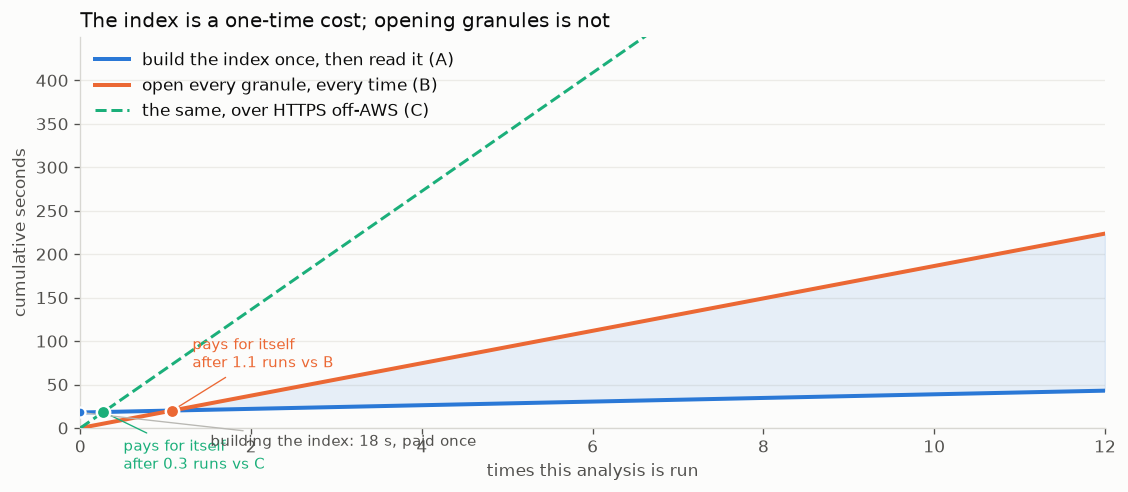

In [17]:
runs = np.linspace(0, 12, 200)
virtual = build_total + runs * a_time
direct_s3 = runs * b_time
direct_https = runs * c_time
be_https = build_total / (c_time - a_time)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.fill_between(runs, virtual, direct_s3, where=direct_s3 >= virtual,
                color=CAT[0], alpha=0.10, zorder=1)
ax.plot(runs, virtual, color=CAT[0], lw=2.4, zorder=3,
        label="build the index once, then read it (A)")
ax.plot(runs, direct_s3, color=CAT[1], lw=2.4, zorder=3,
        label="open every granule, every time (B)")
ax.plot(runs, direct_https, color=CAT[2], lw=1.8, ls="--", zorder=3,
        label="the same, over HTTPS off-AWS (C)")

for be, col, lab in ((breakeven, CAT[1], "vs B"), (be_https, CAT[2], "vs C")):
    ax.plot([be], [build_total + be * a_time], marker="o", ms=8, color=col,
            mec="white", mew=1.5, zorder=5)
    ax.annotate(f"pays for itself\nafter {be:.1f} runs {lab}",
                xy=(be, build_total + be * a_time), xytext=(12, 26 if lab == "vs B" else -34),
                textcoords="offset points", fontsize=9, color=col,
                arrowprops=dict(arrowstyle="-", color=col, lw=0.8))

ax.annotate(f"building the index: {build_total:.0f} s, paid once",
            xy=(0, build_total), xytext=(78, -20), textcoords="offset points",
            fontsize=9, color=INK2,
            arrowprops=dict(arrowstyle="-", color="#b9b8b3", lw=0.8))
ax.plot([0], [build_total], marker="o", ms=6, color=CAT[0], mec="white", mew=1.4, zorder=5)

ax.set_xlabel("times this analysis is run"); ax.set_ylabel("cumulative seconds")
ax.set_xlim(0, 12); ax.set_ylim(0, direct_https[-1] * 0.55)
ax.grid(axis="y"); ax.set_axisbelow(True); ax.legend(loc="upper left")
ax.set_title("The index is a one-time cost; opening granules is not", loc="left",
             fontsize=12, color=INK)
fig.tight_layout()
plt.show()

---
## What this shows, and what it doesn't

**In-region, virtualizing is roughly 8× faster and moves roughly 18× less** — a couple of seconds
against twenty, 61 MB against about a gigabyte, for answers that agree to seven decimal places.
(Exact figures move with the network; the table above is this run.) Path A against path B is the
comparison that matters for anyone already on CryoCloud, and it is not close. What disappears is
not the pixel reads — both paths read the same chunks — but the HDF5 metadata traversal, re-paid
on every granule in every session. The block-size probe in section 6 shows the shape of it: the
AOI's chunks are 2.6 MB per granule, and the direct path moves between 12 and 168 MB, depending on
read-ahead, before it can even find them.

**The data-volume argument is larger than the speed argument.** The answer is 184 bytes; the
granules holding it are 158 GB, some 860 million times more data than result. The virtual path
moves 61 MB of that. Downloading first moves all of it, and then needs 158 GB of disk to put it
on.

**Off-AWS, the protocol switch alone is measurable.** Path C is the same bytes over HTTPS instead
of direct S3, on the same network, and it is slower. A real laptop adds a slower link on top of
that, which section 8 models rather than measures.

**The index has to be built, and it pays back almost immediately.** Roughly one run of one
analysis, on one AOI — because building the index is itself a virtual operation that reads only
metadata, not pixels. Anyone who runs an analysis twice, or shares the cube with one colleague, is
past break-even. That is the argument for putting the index in S3 rather than rebuilding it per
user.

**What this is not.** A single AOI, a single variable, a single track, one machine, one afternoon's
network. The comparison would narrow for an analysis that reads most of every granule, where the
metadata cost stops dominating — virtualization helps least when you need everything. It would
widen for a smaller AOI, a longer record, or more users sharing one index. The laptop columns are
arithmetic on measured byte counts, not measurements; treat them as an order of magnitude. And
path A's timing depends on the cube already existing, which is exactly the point being made — so
section 10 prices that assumption instead of hiding it.